In [65]:
import torch
import torch.nn as nn
print(torch.__version__)
print(torch.cuda.is_available())
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

2.8.0+cu126
True


In [66]:
class CSVDataset(Dataset):
    def __init__(self, path):
        raw = np.loadtxt(path, delimiter=",", dtype=np.float32)
        self.X = torch.from_numpy(raw[:, :-1])
        self.y = torch.from_numpy(raw[:, -1])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


full_train = CSVDataset("data.csv")
test_ds = CSVDataset("test.csv")
batch_size = 256
val_split = 0.05

# per-feature input normalization stats from the TRAINING inputs -> [-1, 1]
x_min = full_train.X.min(dim=0).values
x_max = full_train.X.max(dim=0).values
x_center = (x_min + x_max) / 2          # -> 0 after normalization
x_scale = (x_max - x_min) / 2           # -> +/-1 at the data extremes

# target standardization stats from the TRAINING targets -> mean 0, std 1
y_mean = full_train.y.mean().item()
y_std = full_train.y.std().item()
full_train.y = (full_train.y - y_mean) / y_std   # apply to train (and its val split)
test_ds.y = (test_ds.y - y_mean) / y_std         # apply to test with TRAIN stats

n_val = int(len(full_train) * val_split)
n_train = len(full_train) - n_val
train_ds, val_ds = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

print(f"train batches: {len(train_loader)}, "
      f"val batches: {len(val_loader)}, "
      f"test batches: {len(test_loader)}")
print(f"input center: {x_center.numpy().round(3)}")
print(f"input scale : {x_scale.numpy().round(3)}")
print(f"target standardization: mean={y_mean:.4f}, std={y_std:.4f}")

train batches: 742, val batches: 40, test batches: 782
input center: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
input scale : [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
target standardization: mean=-4.1132, std=8.7022


In [67]:
class SineLayer(nn.Module):
    """Linear layer followed by a sine activation: sin(omega_0 * (W x + b)).

    omega_0 scales the pre-activation. The first layer uses it as a frequency
    factor; later layers divide their weights by omega_0 to keep activation
    magnitudes constant while boosting gradients (SIREN paper, supp. Sec. 1.5).
    """
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features,
                                             1 / self.in_features)
            else:
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class InputNorm(nn.Module):
    """Fixed (non-learnable) input normalization: (x - center) / scale.

    center/scale are stored as buffers, so they move with .to(device) and are
    saved in the state_dict, but receive no gradients. With center/scale fit on
    the training inputs this maps the data range onto [-1, 1] -- the range SIREN's
    first-layer init assumes -- so normalization always travels with the model.
    """
    def __init__(self, center, scale):
        super().__init__()
        self.register_buffer("center", torch.as_tensor(center, dtype=torch.float32))
        self.register_buffer("scale",  torch.as_tensor(scale,  dtype=torch.float32))

    def forward(self, x):
        return (x - self.center) / self.scale


class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features,
                 outermost_linear=True, first_omega_0=30, hidden_omega_0=30.,
                 in_center=None, in_scale=None, y_mean=0.0, y_std=1.0):
        super().__init__()

        # target standardization stats, kept as buffers so predict() can map the
        # network's standardized output back to original units (they travel with
        # .to(device) / state_dict, like InputNorm)
        self.register_buffer("y_mean", torch.tensor(float(y_mean)))
        self.register_buffer("y_std", torch.tensor(float(y_std)))

        net = []
        if in_center is not None:
            net.append(InputNorm(in_center, in_scale))   # fixed normalization, first layer

        net.append(SineLayer(in_features, hidden_features,
                             is_first=True, omega_0=first_omega_0))

        for _ in range(hidden_layers):
            net.append(SineLayer(hidden_features, hidden_features,
                                 is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / hidden_omega_0
                final_linear.weight.uniform_(-bound, bound)
            net.append(final_linear)
        else:
            net.append(SineLayer(hidden_features, out_features,
                                 is_first=False, omega_0=hidden_omega_0))

        self.net = nn.Sequential(*net)

    def forward(self, x):
        # standardized output -- this is what the loss is computed against
        return self.net(x)

    @torch.no_grad()
    def predict(self, x):
        # de-standardize back to original target units for inference / reporting
        return self.forward(x) * self.y_std + self.y_mean

# InputNorm (10) -> first sine layer (10->128) -> 4 sine layers (128->128)
# -> linear output (128->1). Input normalization and target de-standardization
# are both baked into the model.
model = Siren(
    in_features=10,
    hidden_features=128,
    hidden_layers=4,
    out_features=1,
    outermost_linear=True,
    in_center=x_center,
    in_scale=x_scale,
    y_mean=y_mean,
    y_std=y_std,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ndevice: {device} | trainable params: {n_params:,}")

Siren(
  (net): Sequential(
    (0): InputNorm()
    (1): SineLayer(
      (linear): Linear(in_features=10, out_features=128, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (4): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (5): SineLayer(
      (linear): Linear(in_features=128, out_features=128, bias=True)
    )
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

device: cuda | trainable params: 67,585


In [68]:
optim = torch.optim.Adam(lr=5e-5, params=model.parameters())

num_epochs = 150

# cosine-anneal the lr from 5e-5 down to 1e-7 over the run, stepped once per epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim, T_max=num_epochs, eta_min=1e-7)

train_hist, val_hist, lr_hist = [], [], []

step = 0
for epoch in range(num_epochs):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).view(-1, 1)          # match model output shape (B, 1)

        pred = model(x)
        loss = ((pred - y) ** 2).mean()        # MSE, as in the SIREN notebook

        optim.zero_grad()
        loss.backward()
        optim.step()

        running += loss.item()
        step += 1
    # ---- validation ----
    model.eval()
    sse, n = 0.0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device).view(-1, 1)
            pred = model(x)
            sse += ((pred - y) ** 2).sum().item()
            n += y.numel()
    val_mse = sse / n
    train_mse = running / len(train_loader)

    train_hist.append(train_mse)
    val_hist.append(val_mse)
    lr_hist.append(scheduler.get_last_lr()[0])

    scheduler.step()  # decay lr after each epoch
    print(f"== epoch {epoch:2d} done | train MSE {train_mse:.5f} "
          f"| val MSE {val_mse:.5f} | lr {lr_hist[-1]:.2e}")

== epoch  0 done | train MSE 0.57000 | val MSE 0.22214 | lr 5.00e-05
== epoch  1 done | train MSE 0.15336 | val MSE 0.11210 | lr 5.00e-05
== epoch  2 done | train MSE 0.08416 | val MSE 0.07005 | lr 5.00e-05
== epoch  3 done | train MSE 0.05438 | val MSE 0.05020 | lr 5.00e-05
== epoch  4 done | train MSE 0.03746 | val MSE 0.03479 | lr 4.99e-05
== epoch  5 done | train MSE 0.02686 | val MSE 0.02731 | lr 4.99e-05
== epoch  6 done | train MSE 0.01982 | val MSE 0.02037 | lr 4.98e-05
== epoch  7 done | train MSE 0.01504 | val MSE 0.01458 | lr 4.97e-05
== epoch  8 done | train MSE 0.01197 | val MSE 0.01183 | lr 4.97e-05
== epoch  9 done | train MSE 0.00990 | val MSE 0.00954 | lr 4.96e-05
== epoch 10 done | train MSE 0.00746 | val MSE 0.00743 | lr 4.95e-05
== epoch 11 done | train MSE 0.00533 | val MSE 0.00527 | lr 4.93e-05
== epoch 12 done | train MSE 0.00398 | val MSE 0.00421 | lr 4.92e-05
== epoch 13 done | train MSE 0.00327 | val MSE 0.00335 | lr 4.91e-05
== epoch 14 done | train MSE 0.002

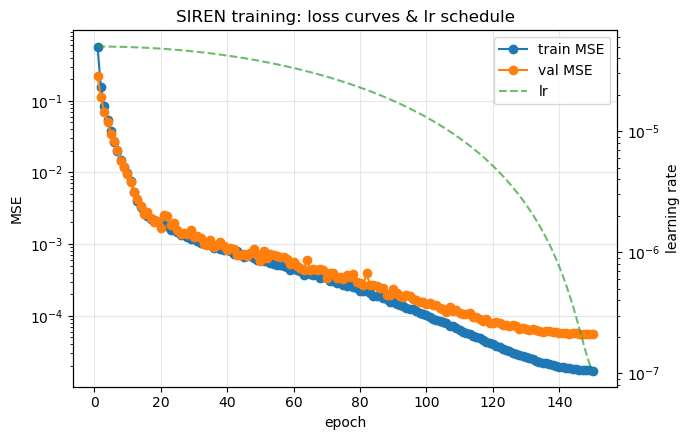

In [69]:
epochs = range(1, len(train_hist) + 1)

fig, ax1 = plt.subplots(figsize=(7, 4.5))

ax1.plot(epochs, train_hist, "-o", label="train MSE", color="tab:blue")
ax1.plot(epochs, val_hist,   "-o", label="val MSE",   color="tab:orange")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.set_yscale("log")          # log scale makes the decay easier to read
ax1.grid(True, alpha=0.3)

# overlay the learning-rate schedule on a second axis
ax2 = ax1.twinx()
ax2.plot(epochs, lr_hist, "--", color="tab:green", alpha=0.7, label="lr")
ax2.set_ylabel("learning rate")
ax2.set_yscale("log")

# merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("SIREN training: loss curves & lr schedule")
plt.tight_layout()
plt.show()

Test set (200000 samples), original units
  MSE  : 0.0014
  RMSE : 0.0378
  MAE  : 0.0269
  R^2  : 1.0000


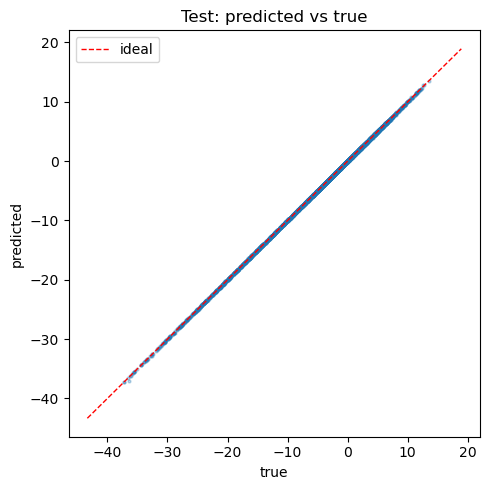

In [70]:
model.eval()
N = len(test_loader.dataset)
preds = np.empty(N, dtype=np.float64)
trues = np.empty(N, dtype=np.float64)

i = 0
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model.predict(x).view(-1).cpu().numpy()      # original target units
        b = out.shape[0]
        preds[i:i + b] = out
        trues[i:i + b] = (y * y_std + y_mean).view(-1).numpy()  # de-standardize target
        i += b

err = preds - trues
mse = np.mean(err ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(err))
r2 = 1 - np.sum(err ** 2) / np.sum((trues - trues.mean()) ** 2)

print(f"Test set ({N} samples), original units")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R^2  : {r2:.4f}")

# parity plot: predicted vs true (subsampled for clarity)
rng = np.random.default_rng(0)
idx = rng.choice(N, size=min(5000, N), replace=False)
lo, hi = trues.min(), trues.max()

plt.figure(figsize=(5, 5))
plt.scatter(trues[idx], preds[idx], s=4, alpha=0.3)
plt.plot([lo, hi], [lo, hi], "r--", lw=1, label="ideal")
plt.xlabel("true")
plt.ylabel("predicted")
plt.title("Test: predicted vs true")
plt.legend()
plt.tight_layout()
plt.show()